# 07. 신규 피처 EDA

## 분석 대상 피처
- **Recency** : `recency_days`
- **주차별 시청** : `dur_w1`, `dur_w2`, `dur_w3`, `dur_w4plus`
- **리텐션** : `retention_w2`, `retention_w3`
- **장르 비율** : `ratio_action_violent` 등 8개


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('features.csv')
print(f'shape: {df.shape}')
print(f'이탈 비율: {df["is_churn"].mean():.1%}')

churn = df[df['is_churn'] == 1]
stay  = df[df['is_churn'] == 0]
print(f'이탈: {len(churn):,}명 / 잔류: {len(stay):,}명')


shape: (17968, 53)
이탈 비율: 33.9%
이탈: 6,092명 / 잔류: 11,876명


---
## 1. Recency (마지막 시청 경과 일수)


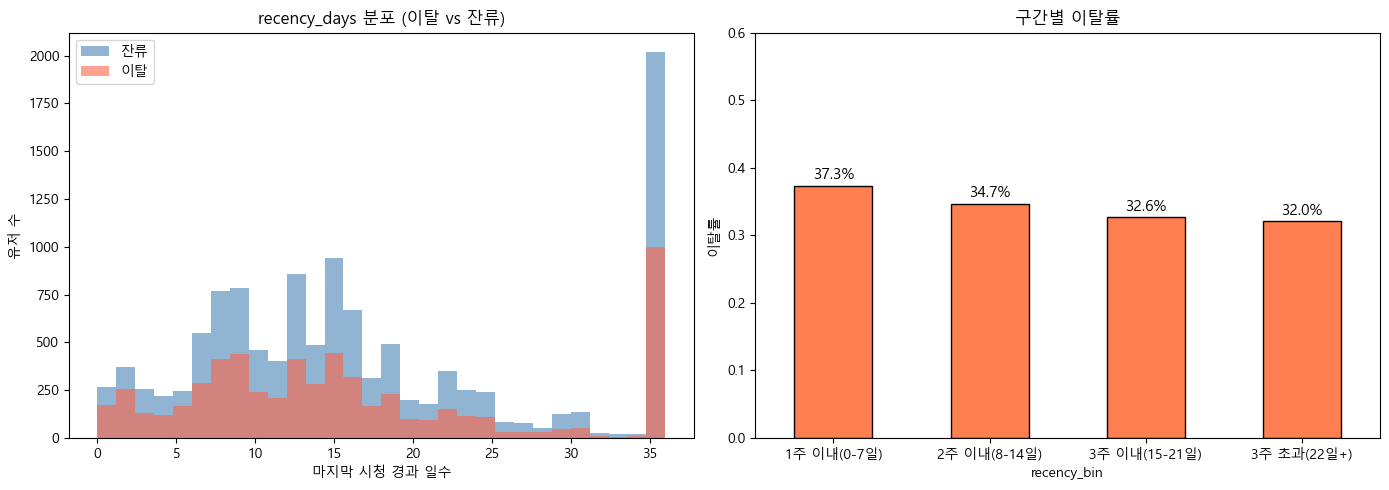

이탈/잔류 recency_days 평균
is_churn
0    17.0
1    16.3
Name: recency_days, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stay['recency_days'],  bins=30, alpha=0.6, label='잔류', color='steelblue')
axes[0].hist(churn['recency_days'], bins=30, alpha=0.6, label='이탈', color='tomato')
axes[0].set_title('recency_days 분포 (이탈 vs 잔류)')
axes[0].set_xlabel('마지막 시청 경과 일수')
axes[0].set_ylabel('유저 수')
axes[0].legend()

df['recency_bin'] = pd.cut(df['recency_days'], bins=[-1,7,14,21,36],
                            labels=['1주 이내(0-7일)','2주 이내(8-14일)','3주 이내(15-21일)','3주 초과(22일+)'])
bychurn = df.groupby('recency_bin', observed=True)['is_churn'].mean()
bychurn.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('구간별 이탈률')
axes[1].set_ylabel('이탈률')
axes[1].set_ylim(0, 0.6)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.01), ha='center', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print('이탈/잔류 recency_days 평균')
print(df.groupby('is_churn')['recency_days'].mean().round(1))


---
## 2. 주차별 시청 시간 (dur_w1 / dur_w2 / dur_w3)


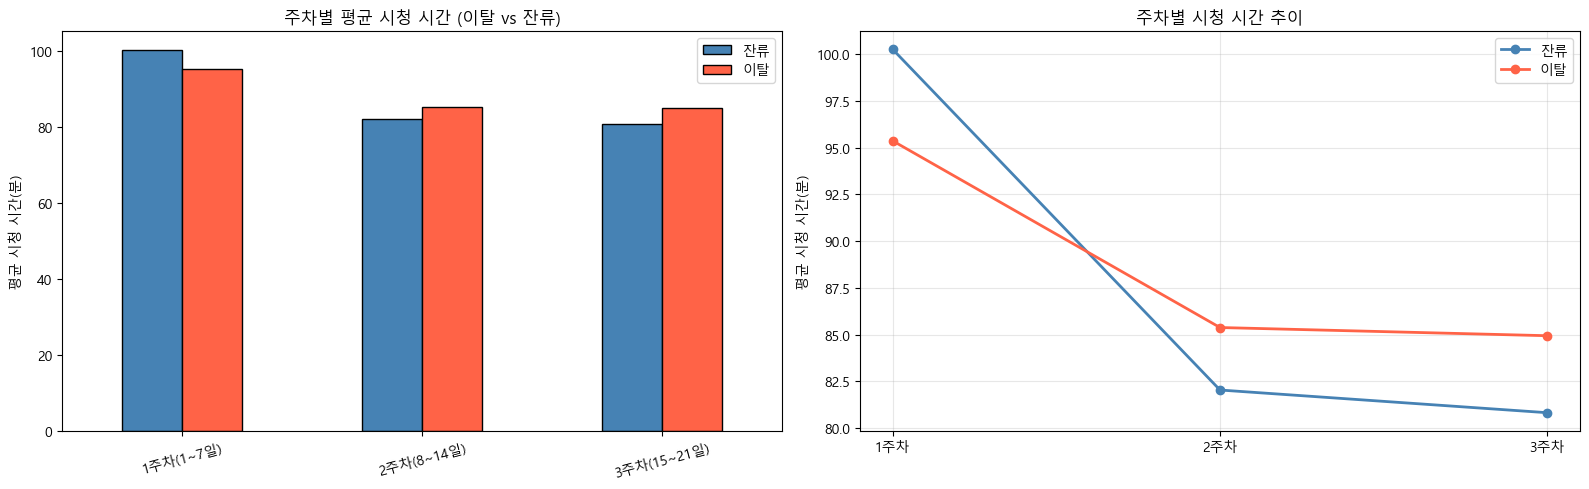

                잔류    이탈
1주차(1~7일)    100.2  95.4
2주차(8~14일)    82.0  85.4
3주차(15~21일)   80.8  84.9


In [11]:
week_cols = ['dur_w1', 'dur_w2', 'dur_w3']
week_labels_ko = ['1주차(1~7일)', '2주차(8~14일)', '3주차(15~21일)']

means = pd.DataFrame({
    '잔류': stay[week_cols].mean(),
    '이탈': churn[week_cols].mean()
})
means.index = week_labels_ko

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

means.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('주차별 평균 시청 시간 (이탈 vs 잔류)')
axes[0].set_ylabel('평균 시청 시간(분)')
axes[0].set_xticklabels(week_labels_ko, rotation=15)
axes[0].legend()

week_labels_short = ['1주차', '2주차', '3주차']
axes[1].plot(week_labels_short, stay[week_cols].mean().values,
             marker='o', label='잔류', color='steelblue', linewidth=2)
axes[1].plot(week_labels_short, churn[week_cols].mean().values,
             marker='o', label='이탈', color='tomato', linewidth=2)
axes[1].set_title('주차별 시청 시간 추이')
axes[1].set_ylabel('평균 시청 시간(분)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(means.round(1))


---
## 3. 리텐션 (retention_w2 / retention_w3)


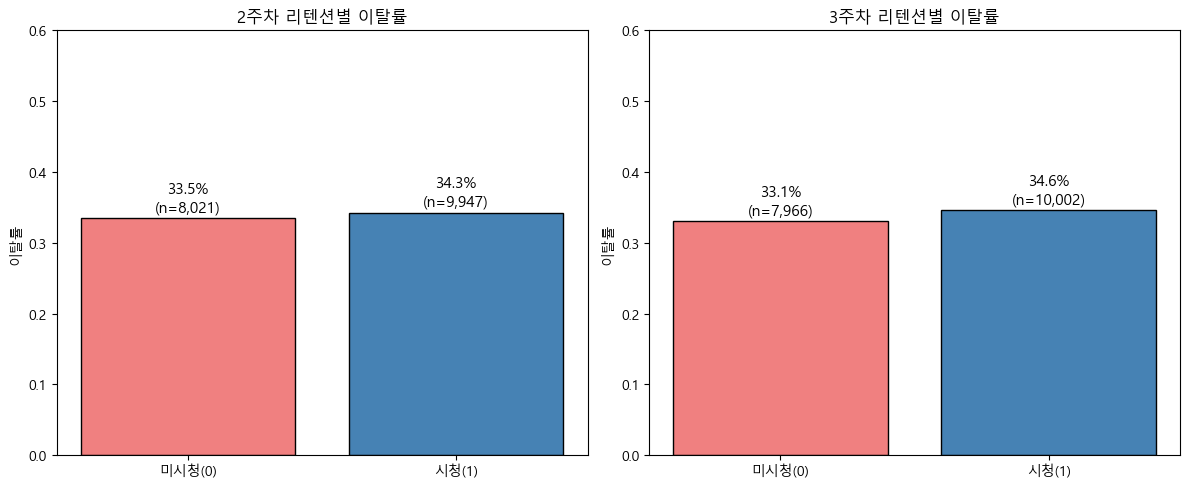

retention_w2 이탈률: retention_w2
0    0.335
1    0.343
Name: is_churn, dtype: float64
retention_w3 이탈률: retention_w3
0    0.331
1    0.346
Name: is_churn, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes, ['retention_w2','retention_w3'], ['2주차 리텐션','3주차 리텐션']):
    ret_churn = df.groupby(col)['is_churn'].mean()
    counts    = df[col].value_counts().sort_index()
    bars = ax.bar(['미시청(0)','시청(1)'], ret_churn.values, color=['lightcoral','steelblue'], edgecolor='black')
    ax.set_title(f'{label}별 이탈률')
    ax.set_ylabel('이탈률')
    ax.set_ylim(0, 0.6)
    for bar, val, cnt in zip(bars, ret_churn.values, counts.values):
        ax.annotate(f'{val:.1%}\n(n={cnt:,})',
                    (bar.get_x()+bar.get_width()/2, bar.get_height()+0.01), ha='center', fontsize=11)

plt.tight_layout()
plt.show()
print('retention_w2 이탈률:', df.groupby('retention_w2')['is_churn'].mean().round(3))
print('retention_w3 이탈률:', df.groupby('retention_w3')['is_churn'].mean().round(3))


In [ ]:
# 특이 케이스: retention_w2=0 이면서 retention_w3=1 (2주차 건너뛰고 3주차 복귀)
skip_w2 = df[(df['retention_w2'] == 0) & (df['retention_w3'] == 1)]
print(f'retention_w2=0 & retention_w3=1 (2주차 스킵 후 복귀): {len(skip_w2):,}명 ({len(skip_w2)/len(df)*100:.1f}%)')
print(f'이 유저들의 이탈률: {skip_w2["is_churn"].mean():.1%}')
print()

# 4가지 패턴 비교
patterns = [
    (0, 0, '둘 다 미시청'),
    (1, 0, 'w2만 시청'),
    (0, 1, 'w3만 시청 (스킵 후 복귀)'),
    (1, 1, '둘 다 시청'),
]
rows = []
for w2, w3, label in patterns:
    subset = df[(df['retention_w2'] == w2) & (df['retention_w3'] == w3)]
    rows.append({'패턴': label, '유저수': len(subset), '이탈률': subset['is_churn'].mean()})

pattern_df = pd.DataFrame(rows)
print(pattern_df.to_string(index=False))

---
## 4. 장르 비율별 이탈률


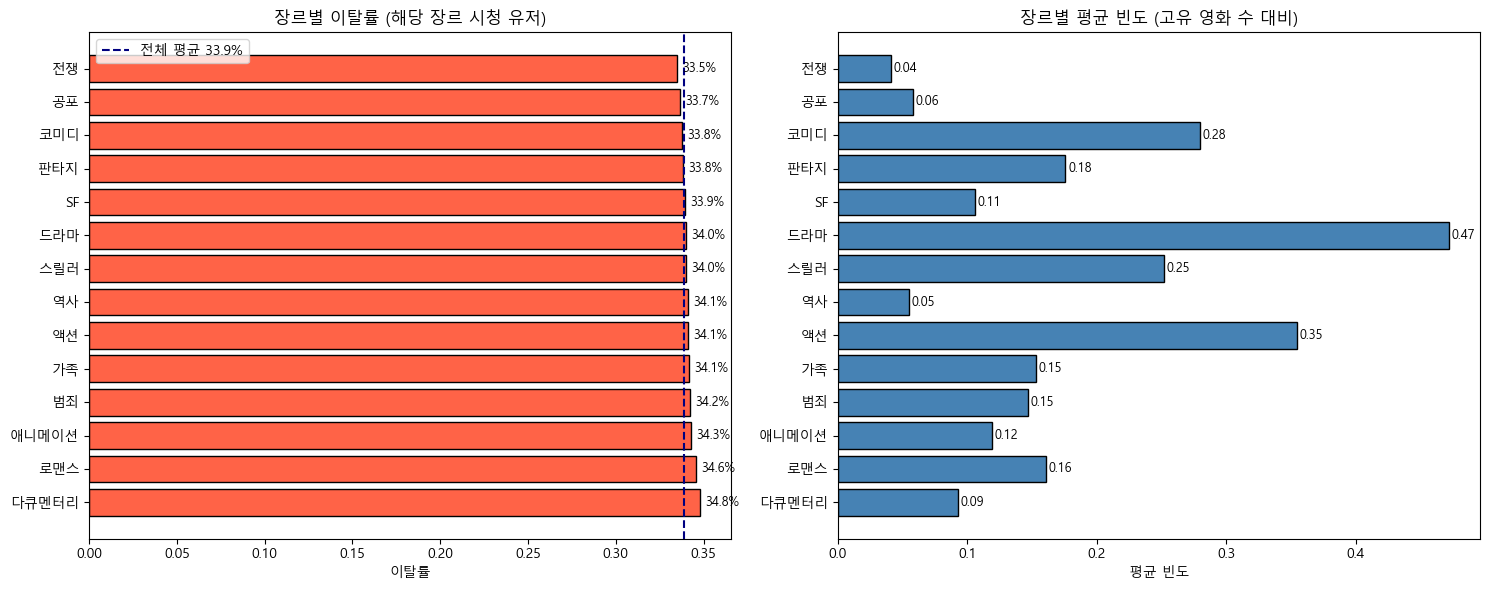

   장르  시청 유저 수      이탈률    평균 빈도
다큐멘터리     5804 0.348036 0.092808
  로맨스     7499 0.345913 0.160418
애니메이션     4524 0.342617 0.118965
   범죄     7448 0.342374 0.146684
   가족     5538 0.341459 0.152908
   액션    11299 0.341358 0.354455
   역사     3793 0.340891 0.054596
  스릴러     9691 0.339800 0.251733
  드라마    12876 0.339779 0.472228
   SF     5306 0.339239 0.105951
  판타지     7356 0.338363 0.175811
  코미디    10528 0.337766 0.279567
   공포     3819 0.336737 0.058093
   전쟁     2905 0.334940 0.040810


In [13]:
genre_cols = ['genre_SF', 'genre_가족', 'genre_공포', 'genre_다큐멘터리', 'genre_드라마', 'genre_로맨스', 'genre_범죄', 'genre_스릴러', 'genre_애니메이션', 'genre_액션', 'genre_역사', 'genre_전쟁', 'genre_코미디', 'genre_판타지']

genre_labels = {'genre_SF': 'SF', 'genre_가족': '가족', 'genre_공포': '공포', 'genre_다큐멘터리': '다큐멘터리', 'genre_드라마': '드라마', 'genre_로맨스': '로맨스', 'genre_범죄': '범죄', 'genre_스릴러': '스릴러', 'genre_애니메이션': '애니메이션', 'genre_액션': '액션', 'genre_역사': '역사', 'genre_전쟁': '전쟁', 'genre_코미디': '코미디', 'genre_판타지': '판타지'}

results = []
for col in genre_cols:
    viewers = df[df[col] > 0]
    results.append({
        '장르': genre_labels[col],
        '시청 유저 수': len(viewers),
        '이탈률': viewers['is_churn'].mean(),
        '평균 빈도': df[col].mean()
    })

result_df = pd.DataFrame(results).sort_values('이탈률', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars = axes[0].barh(result_df['장르'], result_df['이탈률'], color='tomato', edgecolor='black')
axes[0].axvline(df['is_churn'].mean(), color='navy', linestyle='--', label=f'전체 평균 {df["is_churn"].mean():.1%}')
axes[0].set_title('장르별 이탈률 (해당 장르 시청 유저)')
axes[0].set_xlabel('이탈률')
axes[0].legend()
for bar, val in zip(bars, result_df['이탈률']):
    axes[0].annotate(f'{val:.1%}', (val+0.003, bar.get_y()+bar.get_height()/2), va='center', fontsize=9)

bars2 = axes[1].barh(result_df['장르'], result_df['평균 빈도'], color='steelblue', edgecolor='black')
axes[1].set_title('장르별 평균 빈도 (고유 영화 수 대비)')
axes[1].set_xlabel('평균 빈도')
for bar, val in zip(bars2, result_df['평균 빈도']):
    axes[1].annotate(f'{val:.2f}', (val+0.002, bar.get_y()+bar.get_height()/2), va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(result_df.to_string(index=False))


---
## 5. 주력 장르 (최대 비율 장르) 기준 이탈률


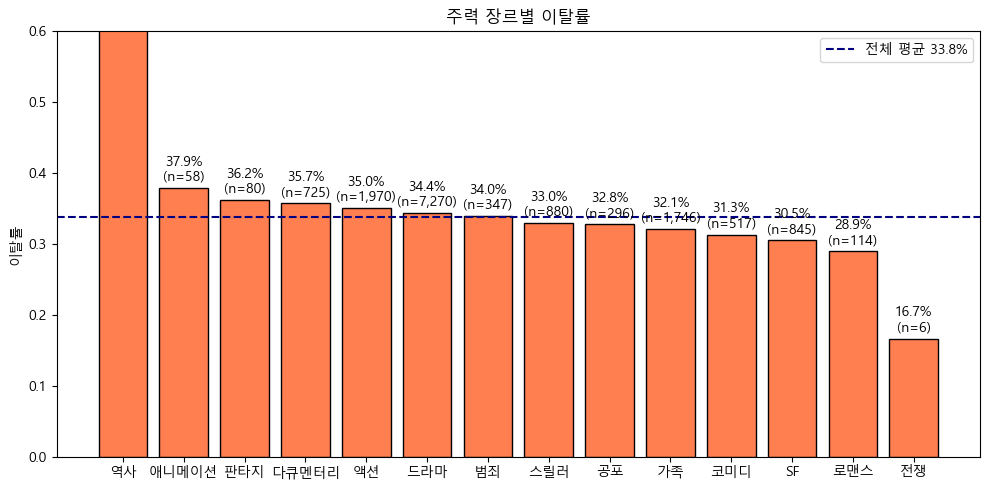

main_genre  유저수      이탈률
        역사    1 1.000000
     애니메이션   58 0.379310
       판타지   80 0.362500
     다큐멘터리  725 0.357241
        액션 1970 0.350254
       드라마 7270 0.344017
        범죄  347 0.340058
       스릴러  880 0.329545
        공포  296 0.327703
        가족 1746 0.321306
       코미디  517 0.313346
        SF  845 0.305325
       로맨스  114 0.289474
        전쟁    6 0.166667


In [14]:
df_watch = df[df[genre_cols].sum(axis=1) > 0].copy()
df_watch['main_genre'] = df_watch[genre_cols].idxmax(axis=1).map(genre_labels)

churn_by_genre = df_watch.groupby('main_genre').agg(
    유저수=('is_churn','count'),
    이탈률=('is_churn','mean')
).sort_values('이탈률', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(churn_by_genre['main_genre'], churn_by_genre['이탈률'], color='coral', edgecolor='black')
ax.axhline(df_watch['is_churn'].mean(), color='navy', linestyle='--',
           label=f'전체 평균 {df_watch["is_churn"].mean():.1%}')
ax.set_title('주력 장르별 이탈률')
ax.set_ylabel('이탈률')
ax.set_ylim(0, 0.6)
for bar, row in zip(bars, churn_by_genre.itertuples()):
    ax.annotate(f'{row.이탈률:.1%}\n(n={row.유저수:,})',
                (bar.get_x()+bar.get_width()/2, bar.get_height()+0.01), ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()
print(churn_by_genre.to_string(index=False))


---
## 6. 신규 피처 상관관계 (이탈과의 관계)


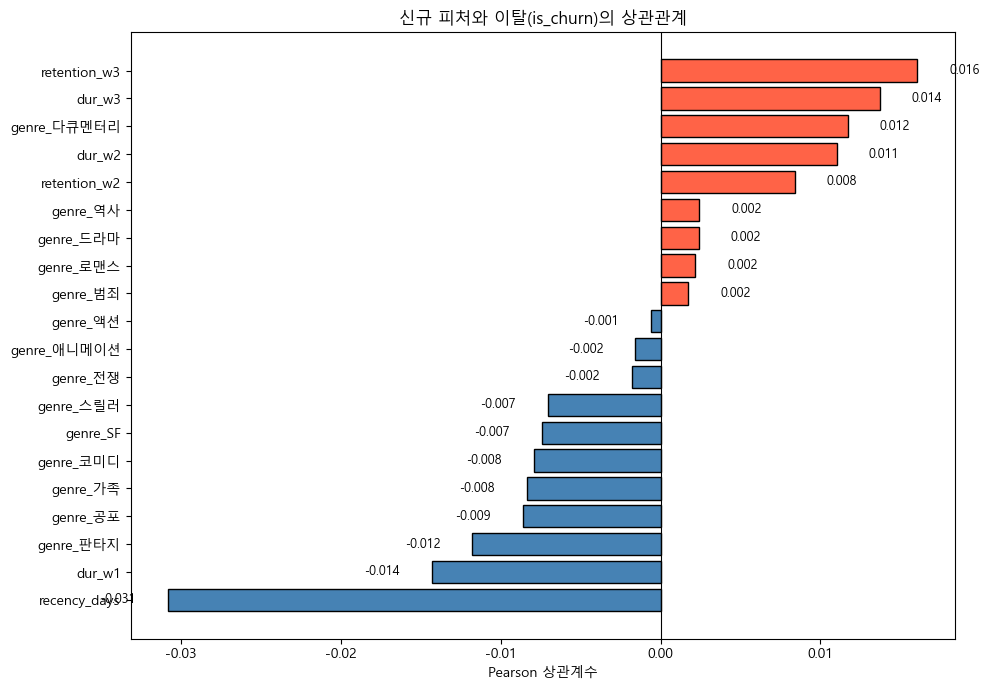

In [15]:
new_feat_cols = ['recency_days','dur_w1','dur_w2','dur_w3','retention_w2','retention_w3'] + genre_cols

corr = df[new_feat_cols + ['is_churn']].corr()['is_churn'].drop('is_churn').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('신규 피처와 이탈(is_churn)의 상관관계')
ax.set_xlabel('Pearson 상관계수')
for bar, val in zip(bars, corr.values):
    offset = 0.002 if val >= 0 else -0.002
    ha = 'left' if val >= 0 else 'right'
    ax.annotate(f'{val:.3f}', (val+offset, bar.get_y()+bar.get_height()/2), va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.show()


---
## 7. 종합 요약


In [16]:
print('=== 신규 피처 이탈률 요약 ===')
print()
print('[Recency]')
print(f'  이탈 평균: {churn["recency_days"].mean():.1f}일 | 잔류 평균: {stay["recency_days"].mean():.1f}일')
print()
print('[주차별 시청 시간 평균]')
for col in ['dur_w1','dur_w2','dur_w3']:
    print(f'  {col}: 이탈={churn[col].mean():.1f}분 | 잔류={stay[col].mean():.1f}분')
print()
print('[리텐션]')
for col in ['retention_w2','retention_w3']:
    r0 = df[df[col]==0]['is_churn'].mean()
    r1 = df[df[col]==1]['is_churn'].mean()
    print(f'  {col}: 미시청={r0:.1%} | 시청={r1:.1%} (차이: {abs(r0-r1):.1%}p)')
print()
print('[장르별 이탈률 (시청 유저 기준, 빈도 방식)]')
for _, row in result_df.iterrows():
    print(f'  {row["장르"]}: {row["이탈률"]:.1%} (n={int(row["시청 유저 수"]):,})')


=== 신규 피처 이탈률 요약 ===

[Recency]
  이탈 평균: 16.3일 | 잔류 평균: 17.0일

[주차별 시청 시간 평균]
  dur_w1: 이탈=95.4분 | 잔류=100.2분
  dur_w2: 이탈=85.4분 | 잔류=82.0분
  dur_w3: 이탈=84.9분 | 잔류=80.8분

[리텐션]
  retention_w2: 미시청=33.5% | 시청=34.3% (차이: 0.8%p)
  retention_w3: 미시청=33.1% | 시청=34.6% (차이: 1.5%p)

[장르별 이탈률 (시청 유저 기준, 빈도 방식)]
  다큐멘터리: 34.8% (n=5,804)
  로맨스: 34.6% (n=7,499)
  애니메이션: 34.3% (n=4,524)
  범죄: 34.2% (n=7,448)
  가족: 34.1% (n=5,538)
  액션: 34.1% (n=11,299)
  역사: 34.1% (n=3,793)
  스릴러: 34.0% (n=9,691)
  드라마: 34.0% (n=12,876)
  SF: 33.9% (n=5,306)
  판타지: 33.8% (n=7,356)
  코미디: 33.8% (n=10,528)
  공포: 33.7% (n=3,819)
  전쟁: 33.5% (n=2,905)
